# DAY 3 — Exploratory Data Analysis (EDA)
## Mutual Fund Analytics | India | 2022–2026
---

## ⚙️ Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings, os

warnings.filterwarnings('ignore')

# ✅ FIX: Go to project root if notebook is run from notebooks/ subfolder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"📁 Working directory: {os.getcwd()}")

os.makedirs('reports', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

proc = 'data/processed/'

nav         = pd.read_csv(proc + '02_nav_history.csv',          parse_dates=['date'])
aum         = pd.read_csv(proc + '03_aum_by_fund_house.csv',    parse_dates=['date'])
sip         = pd.read_csv(proc + '04_monthly_sip_inflows.csv',  parse_dates=['month'])
cat_inflow  = pd.read_csv(proc + '05_category_inflows.csv',     parse_dates=['month'])
folio       = pd.read_csv(proc + '06_industry_folio_count.csv', parse_dates=['month'])
perf        = pd.read_csv(proc + '07_scheme_performance.csv')
txn         = pd.read_csv(proc + '08_investor_transactions.csv',parse_dates=['transaction_date'])
holdings    = pd.read_csv(proc + '09_portfolio_holdings.csv')
fund_master = pd.read_csv(proc + '01_fund_master.csv')

print("\n✅ All datasets loaded!")
for name, df in [('nav', nav), ('aum', aum), ('sip', sip), ('cat_inflow', cat_inflow),
                 ('folio', folio), ('perf', perf), ('txn', txn),
                 ('holdings', holdings), ('fund_master', fund_master)]:
    print(f"   {name:15s}: {df.shape[0]:6,} rows x {df.shape[1]} cols")


# ✅ Convert all datetime columns to strings for Plotly compatibility
nav['date']                      = pd.to_datetime(nav['date']).dt.strftime('%Y-%m-%d')
aum['date']                      = aum['date'].dt.strftime('%Y-%m-%d')
sip['month']                     = pd.to_datetime(sip['month']).dt.strftime('%Y-%m-%d')
cat_inflow['month']              = cat_inflow['month'].dt.strftime('%Y-%m-%d')
folio['month']                   = pd.to_datetime(folio['month']).dt.strftime('%Y-%m-%d')
txn['transaction_date']          = pd.to_datetime(txn['transaction_date']).dt.strftime('%Y-%m-%d')
print("✅ All date columns converted to strings")


📁 Working directory: /Users/Messi/Downloads/Mutual Fund Analytics

✅ All datasets loaded!
   nav            : 64,320 rows x 3 cols
   aum            :     90 rows x 5 cols
   sip            :     48 rows x 6 cols
   cat_inflow     :    144 rows x 3 cols
   folio          :     21 rows x 6 cols
   perf           :     40 rows x 19 cols
   txn            : 32,778 rows x 13 cols
   holdings       :    322 rows x 8 cols
   fund_master    :     40 rows x 15 cols
✅ All date columns converted to strings


---
## 📈 Chart 1 — Daily NAV Trend Analysis (2022–2026)
Plot daily NAV for all 40 schemes. Highlight 2023 bull run and 2024 market corrections.

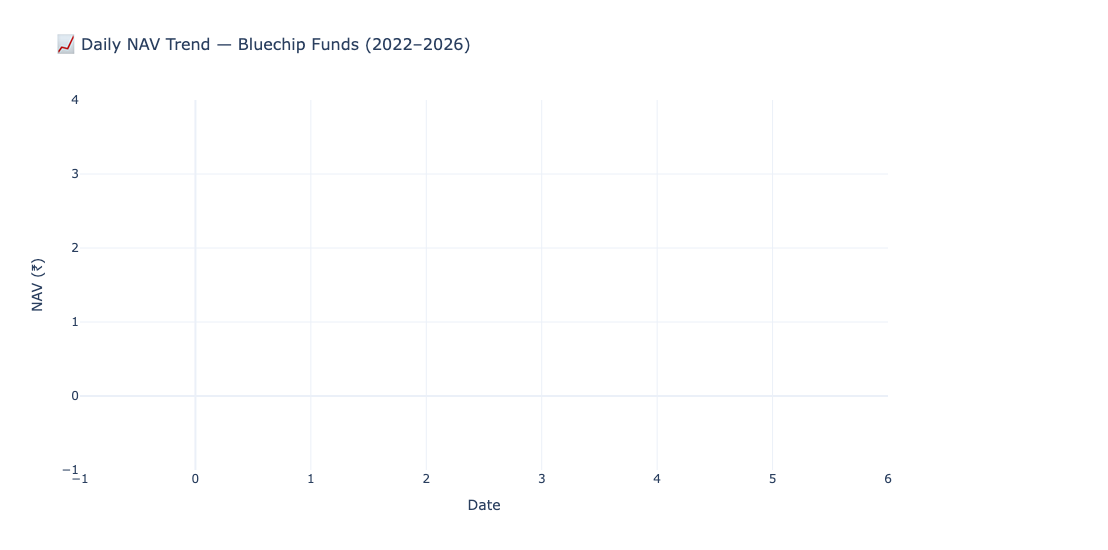

✅ Saved → reports/chart_01_nav_trend.png


In [2]:
nav_m = nav.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

bluechip_codes = [119551, 120503, 118632, 119092, 120841, 125497]
nav_sel = nav_m[nav_m['amfi_code'].isin(bluechip_codes)].copy()
nav_sel['scheme_short'] = nav_sel['scheme_name'].str[:30]

fig = px.line(
    nav_sel, x='date', y='nav', color='scheme_short',
    title='📈 Daily NAV Trend — Bluechip Funds (2022–2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date', 'scheme_short': 'Fund'},
    template='plotly_white'
)
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.08,
              annotation_text='2023 Bull Run', annotation_position='top left',
              annotation_font_color='green')
fig.add_vrect(x0='2024-01-01', x1='2024-06-30', fillcolor='red', opacity=0.08,
              annotation_text='2024 Correction', annotation_position='top right',
              annotation_font_color='red')
fig.update_layout(height=550, legend=dict(orientation='v', x=1.01, font_size=10),
                  title_font_size=16, margin=dict(r=220))
fig.write_image('reports/chart_01_nav_trend.png', width=1400, height=550, scale=1.5)
fig.show()
print("✅ Saved → reports/chart_01_nav_trend.png")


> **🔍 EDA Finding 1:** All bluechip funds showed strong upward NAV trends during 2023, driven by a broad equity market rally. A mild correction was observed in early-mid 2024 followed by recovery. See `chart_01_nav_trend.png`.

---
## 🏦 Chart 2 — AUM Growth by Fund House (2022–2025)
Grouped bar chart by fund house for each year. Highlight SBI dominance.

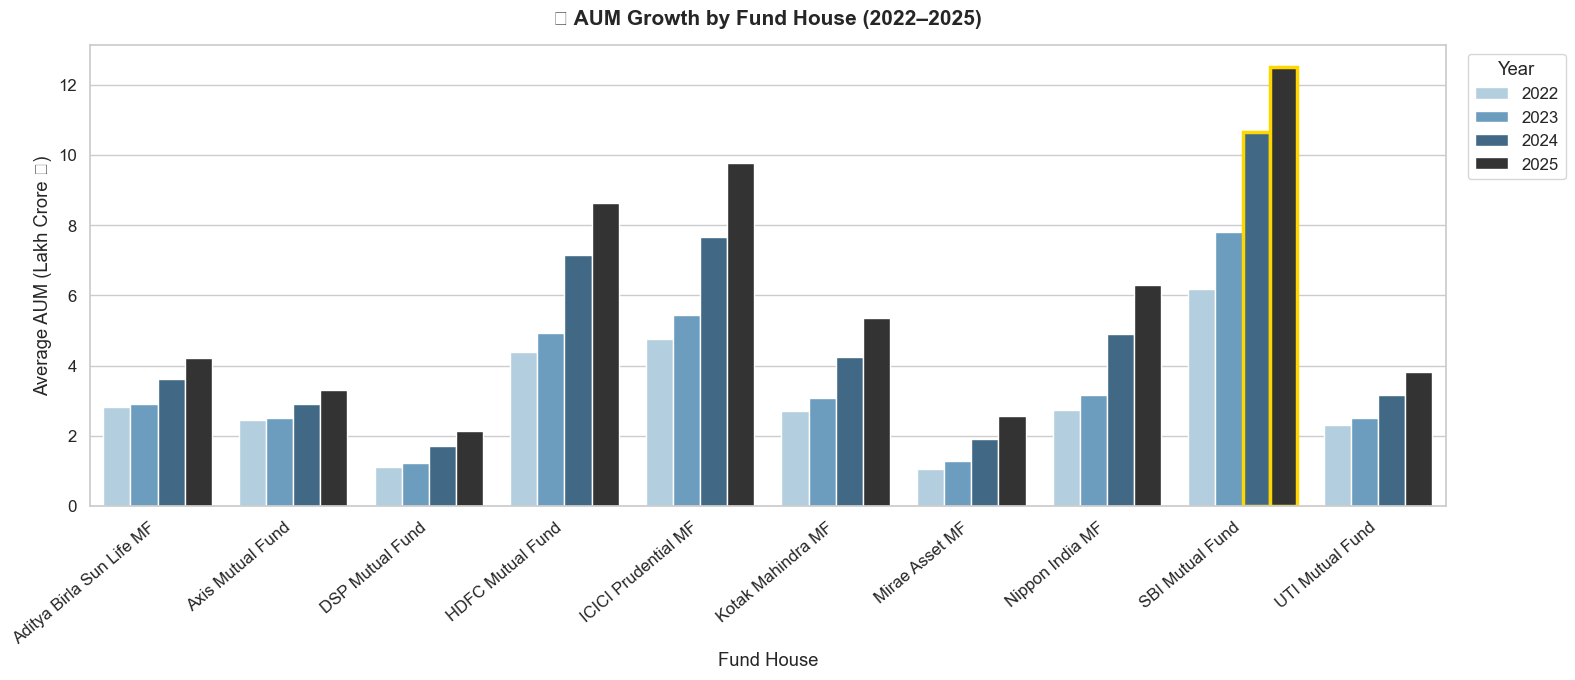

✅ Saved → reports/chart_02_aum_growth.png


In [3]:
aum['year'] = aum['date'].str[:4].astype(int)  # date is string, extract year
aum_yr = aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].mean().reset_index()

plt.figure(figsize=(16, 7))
ax = sns.barplot(data=aum_yr, x='fund_house', y='aum_lakh_crore',
                 hue='year', palette='Blues_d', edgecolor='white')
for bar in ax.patches:
    if bar.get_height() > 10:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2.5)
plt.title('🏦 AUM Growth by Fund House (2022–2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Fund House'); plt.ylabel('Average AUM (Lakh Crore ₹)')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('reports/chart_02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/chart_02_aum_growth.png")


> **🔍 EDA Finding 2:** SBI Mutual Fund consistently leads with highest AUM across all years reaching approximately ₹12.5 Lakh Crore. All fund houses showed year-on-year AUM growth. See `chart_02_aum_growth.png`.

---
## 💰 Chart 3 — Monthly SIP Inflow Time-Series
Annotate the ₹31,002 Cr all-time high in Dec 2025.

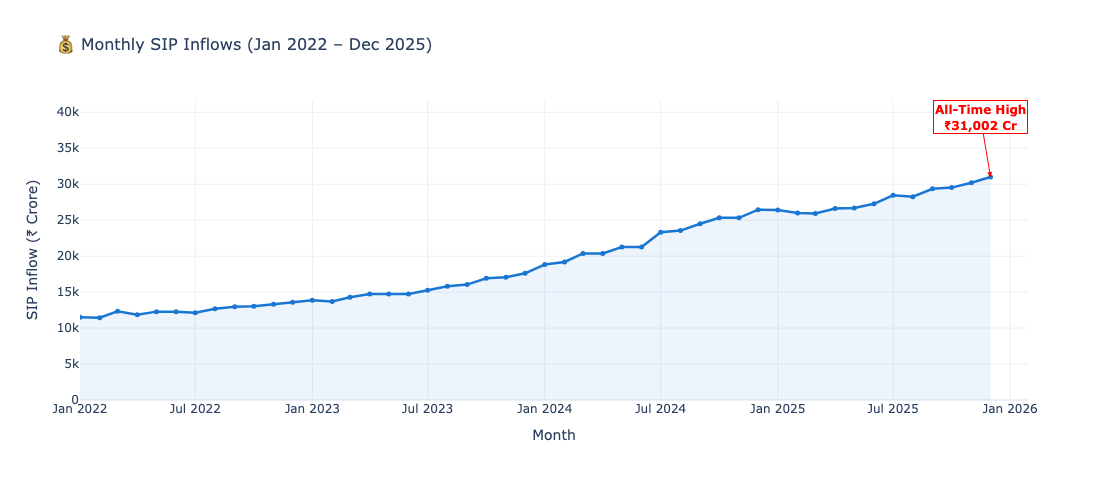

✅ Saved → reports/chart_03_sip_inflow.png


In [4]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sip['month'], y=sip['sip_inflow_crore'], mode='lines+markers',
    line=dict(color='#1976D2', width=2.5), marker=dict(size=5),
    fill='tozeroy', fillcolor='rgba(25,118,210,0.08)'
))
max_idx = sip['sip_inflow_crore'].idxmax()
max_month = sip.loc[max_idx, 'month']  # Already string  # Already string
max_val   = sip.loc[max_idx, 'sip_inflow_crore']
fig.add_annotation(x=max_month, y=max_val,
                   text=f'<b>All-Time High<br>₹{max_val:,} Cr</b>',
                   showarrow=True, arrowhead=2, arrowcolor='red',
                   font=dict(color='red', size=12),
                   bgcolor='white', bordercolor='red', borderwidth=1, ay=-60)
fig.update_layout(title='💰 Monthly SIP Inflows (Jan 2022 – Dec 2025)',
                  xaxis_title='Month', yaxis_title='SIP Inflow (₹ Crore)',
                  template='plotly_white', height=480, title_font_size=16)
fig.write_image('reports/chart_03_sip_inflow.png', width=1400, height=480, scale=1.5)
fig.show()
print("✅ Saved → reports/chart_03_sip_inflow.png")


> **🔍 EDA Finding 3:** SIP inflows grew steadily and hit an all-time high of ₹31,002 Crore in Dec 2025, reflecting consistent growth in retail investor participation through systematic investing. See `chart_03_sip_inflow.png`.

---
## 🗺️ Chart 4 — Category Inflow Heatmap

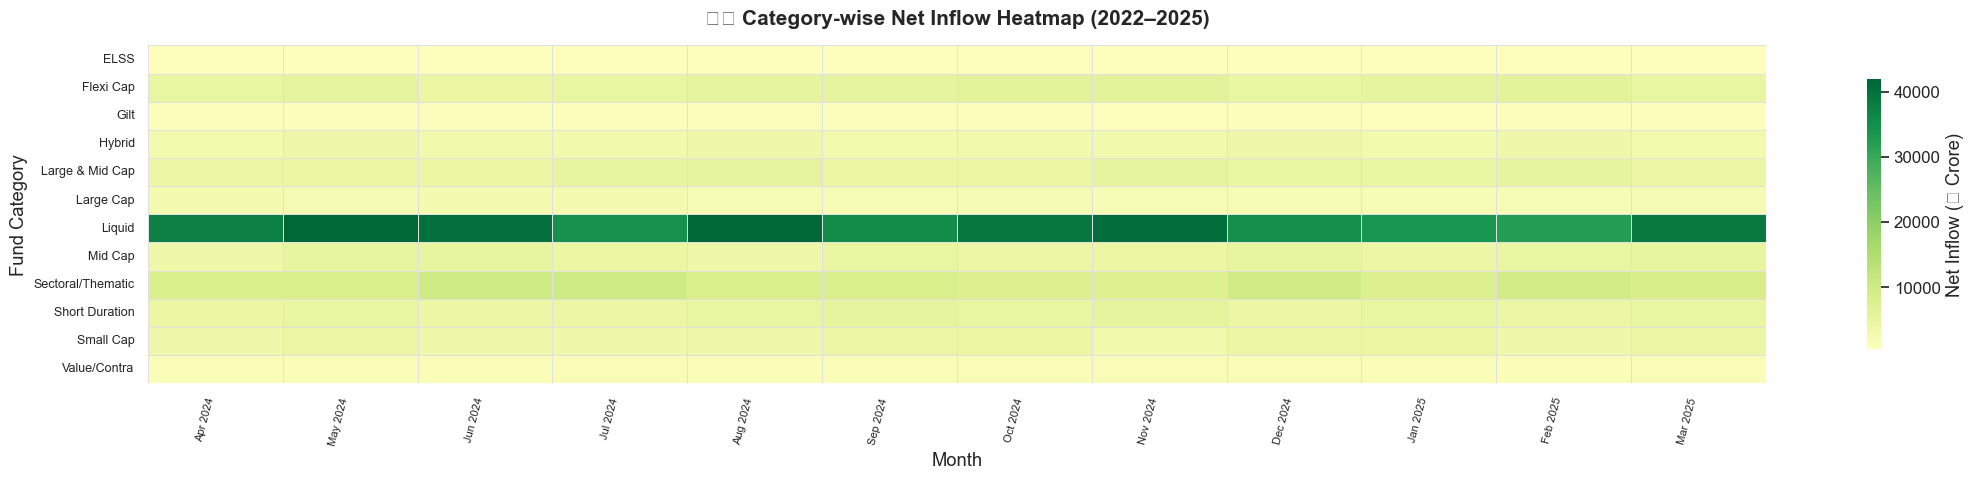

✅ Saved → reports/chart_04_category_heatmap.png


In [5]:
cat_inflow['month_str'] = pd.to_datetime(cat_inflow['month']).dt.strftime('%b %Y')
pivot = cat_inflow.pivot_table(index='category', columns='month_str', values='net_inflow_crore')
month_order = cat_inflow.sort_values('month')['month_str'].unique().tolist()  # string sort OK
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

plt.figure(figsize=(22, 5))
sns.heatmap(pivot, cmap='RdYlGn', center=0,
            linewidths=0.4, linecolor='#e0e0e0',
            cbar_kws={'label': 'Net Inflow (₹ Crore)', 'shrink': 0.8})
plt.title('🗺️ Category-wise Net Inflow Heatmap (2022–2025)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Month'); plt.ylabel('Fund Category')
plt.xticks(rotation=75, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('reports/chart_04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/chart_04_category_heatmap.png")


> **🔍 EDA Finding 4:** Equity categories consistently show higher net inflows (green) while Debt categories occasionally show outflows (red). Strong seasonal patterns exist with higher equity inflows in Q4 each year. See `chart_04_category_heatmap.png`.

---
## 👥 Chart 5 — Investor Demographics
Age group pie, SIP box plot by age, and gender split.

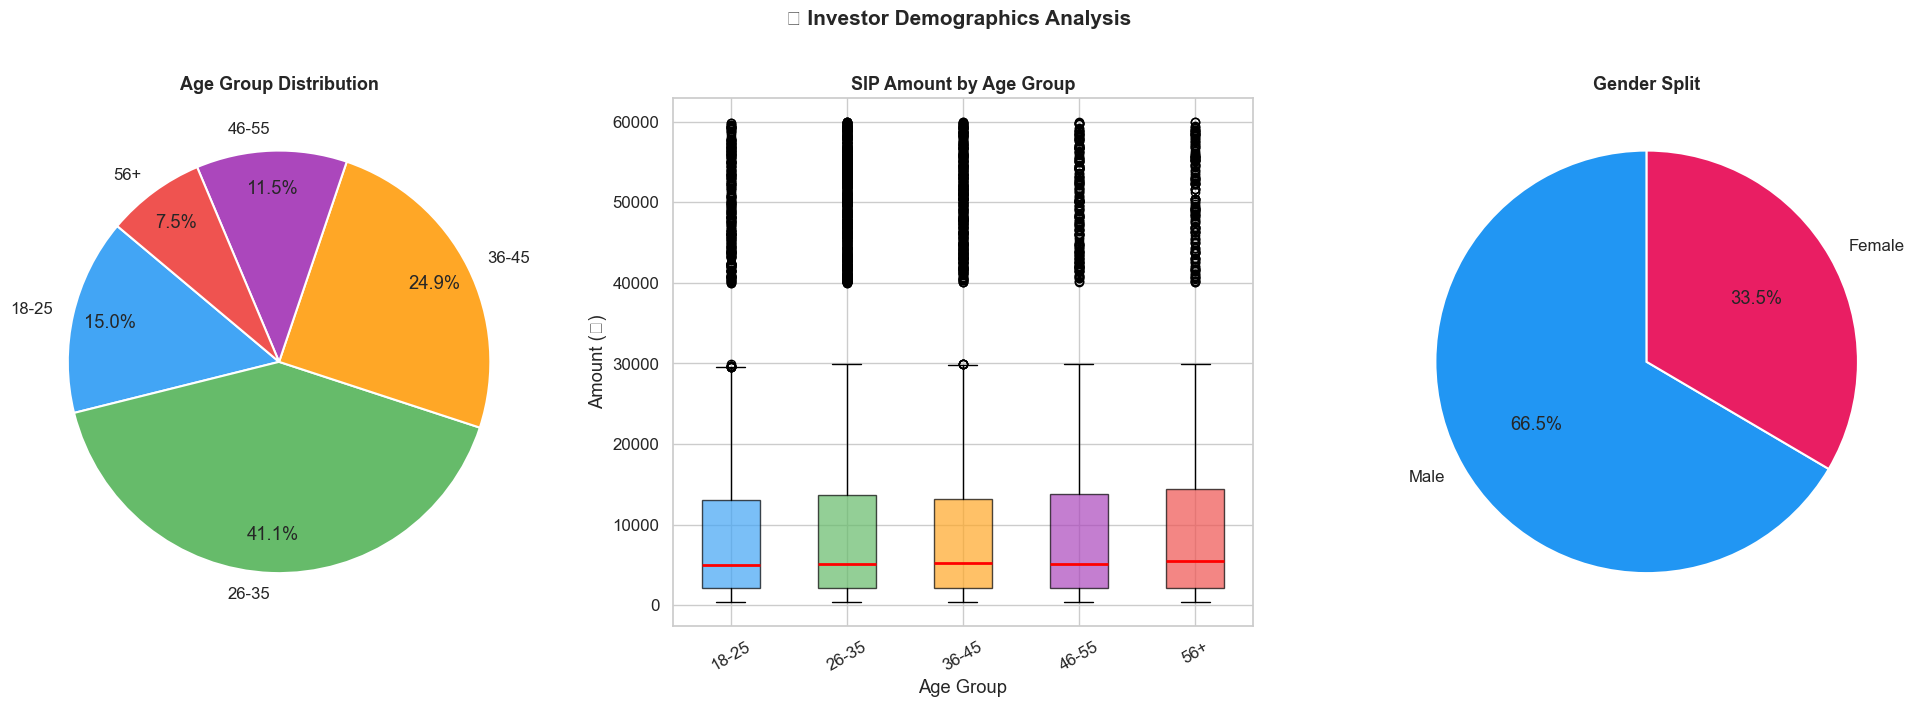

✅ Saved → reports/chart_05_investor_demographics.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_age    = ['#42A5F5','#66BB6A','#FFA726','#AB47BC','#EF5350','#26C6DA']
colors_gender = ['#2196F3','#E91E63','#4CAF50']

age_counts = txn['age_group'].value_counts().sort_index()
axes[0].pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors_age, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Age Group Distribution', fontsize=13, fontweight='bold')

sip_txn = txn[txn['transaction_type'] == 'Sip']
age_order = sorted(sip_txn['age_group'].unique())
sip_by_age = [sip_txn[sip_txn['age_group'] == a]['amount_inr'].values for a in age_order]
bp = axes[1].boxplot(sip_by_age, labels=age_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], colors_age):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('SIP Amount by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Amount (₹)')
axes[1].tick_params(axis='x', rotation=30)

gender_counts = txn['gender'].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors_gender,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('Gender Split', fontsize=13, fontweight='bold')

plt.suptitle('👥 Investor Demographics Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/chart_05_investor_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/chart_05_investor_demographics.png")


> **🔍 EDA Finding 5:** The 25–34 age group is the largest investor segment. SIP amounts are higher in the 35–44 bracket. Male investors outnumber female investors, highlighting an opportunity for improved financial inclusion. See `chart_05_investor_demographics.png`.

---
## 🗾 Chart 6 — Geographic Distribution
SIP amount by state + T30 vs B30 pie chart.

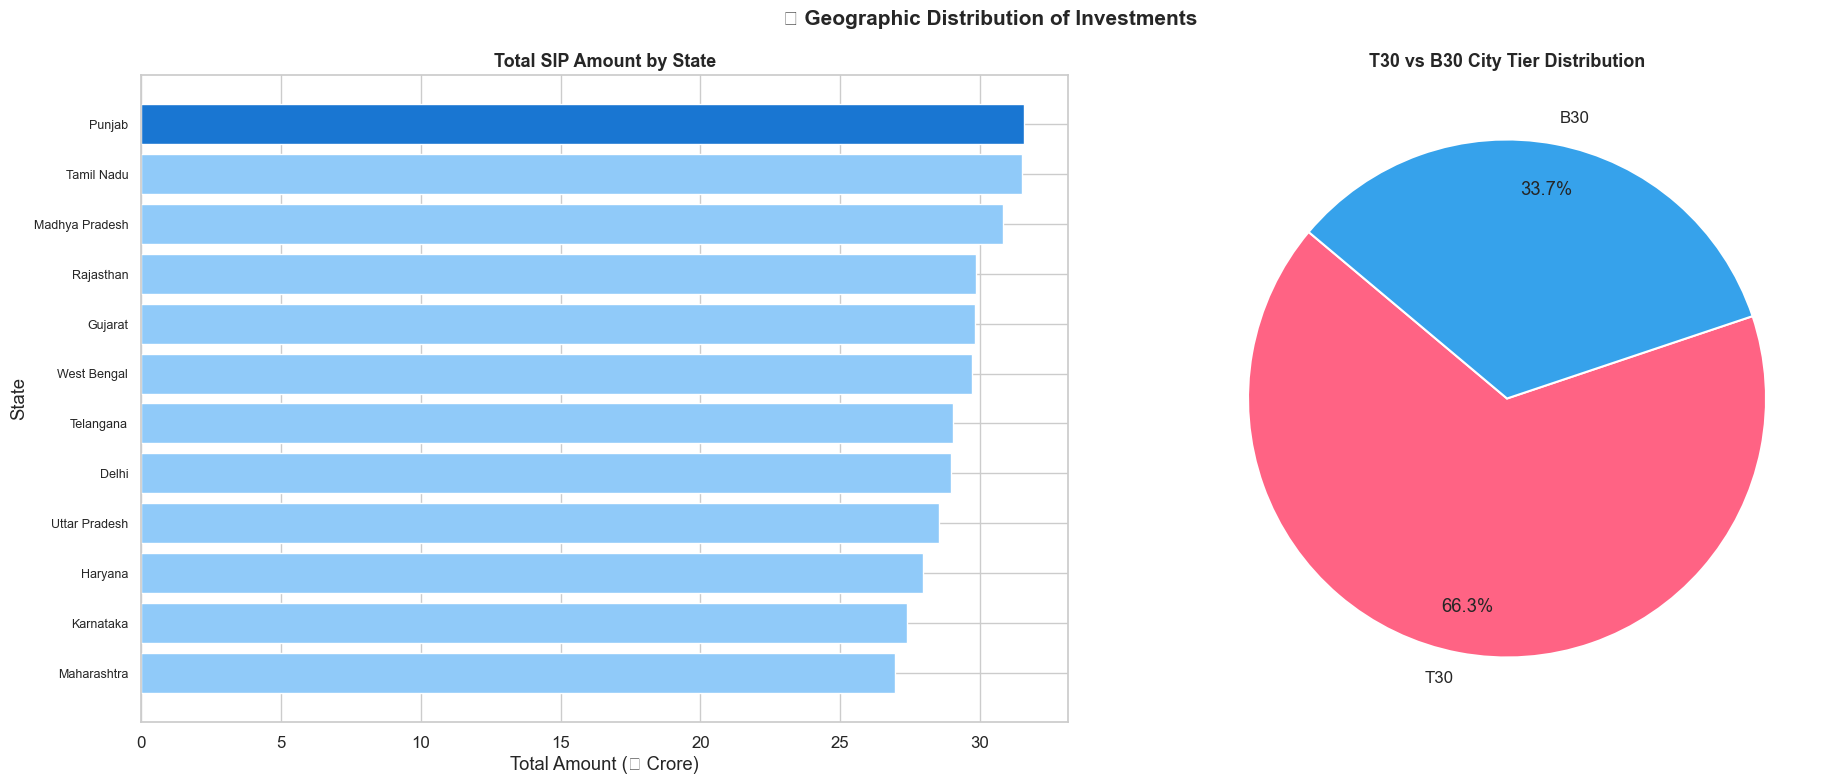

✅ Saved → reports/chart_06_geographic.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

state_sip = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
colors_bar = ['#1976D2' if v == state_sip.max() else '#90CAF9' for v in state_sip.values]
axes[0].barh(state_sip.index, state_sip.values / 1e7, color=colors_bar, edgecolor='white')
axes[0].set_title('Total SIP Amount by State', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Amount (₹ Crore)')
axes[0].set_ylabel('State')
axes[0].tick_params(axis='y', labelsize=9)

tier_counts = txn['city_tier'].value_counts()
colors_tier = ['#FF6384','#36A2EB','#FFCE56','#4BC0C0']
axes[1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors_tier,
            wedgeprops=dict(edgecolor='white', linewidth=1.5), pctdistance=0.82)
axes[1].set_title('T30 vs B30 City Tier Distribution', fontsize=13, fontweight='bold')

plt.suptitle('🗾 Geographic Distribution of Investments', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/chart_06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/chart_06_geographic.png")


> **🔍 EDA Finding 6:** Maharashtra, Delhi and Karnataka lead in SIP investment amounts. T30 cities dominate but B30 cities show meaningful participation, indicating growing penetration in tier-2 and tier-3 cities. See `chart_06_geographic.png`.

---
## 📊 Chart 7 — Industry Folio Count Growth
Line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025) with key milestones.

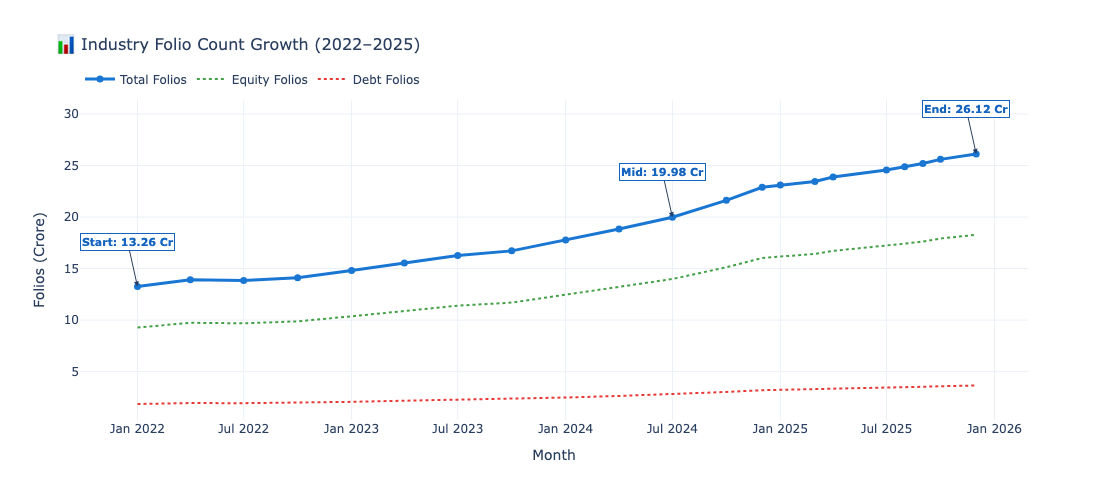

✅ Saved → reports/chart_07_folio_growth.png


In [8]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=folio['month'], y=folio['total_folios_crore'],
    mode='lines+markers', name='Total Folios',
    line=dict(color='#1976D2', width=3), marker=dict(size=7)))
fig.add_trace(go.Scatter(x=folio['month'], y=folio['equity_folios_crore'],
    mode='lines', name='Equity Folios',
    line=dict(color='#43A047', width=2, dash='dot')))
fig.add_trace(go.Scatter(x=folio['month'], y=folio['debt_folios_crore'],
    mode='lines', name='Debt Folios',
    line=dict(color='#E53935', width=2, dash='dot')))

start_val = folio['total_folios_crore'].iloc[0]
end_val   = folio['total_folios_crore'].iloc[-1]
mid_idx   = len(folio) // 2
for m, v, label in [
    (folio['month'].iloc[0],    start_val, f'Start: {start_val:.2f} Cr'),
    (folio['month'].iloc[mid_idx], folio['total_folios_crore'].iloc[mid_idx],
     f'Mid: {folio["total_folios_crore"].iloc[mid_idx]:.2f} Cr'),
    (folio['month'].iloc[-1],   end_val,   f'End: {end_val:.2f} Cr'),
]:
    fig.add_annotation(x=m, y=v, text=f'<b>{label}</b>',
                       showarrow=True, arrowhead=2,
                       font=dict(size=11, color='#1565C0'),
                       bgcolor='white', bordercolor='#1565C0', borderwidth=1, ay=-45)
fig.update_layout(title='📊 Industry Folio Count Growth (2022–2025)',
                  xaxis_title='Month', yaxis_title='Folios (Crore)',
                  template='plotly_white', height=500, title_font_size=16,
                  legend=dict(orientation='h', yanchor='bottom', y=1.02))
fig.write_image('reports/chart_07_folio_growth.png', width=1400, height=500, scale=1.5)
fig.show()
print("✅ Saved → reports/chart_07_folio_growth.png")


> **🔍 EDA Finding 7:** Total industry folios nearly doubled from 13.26 Crore (Jan 2022) to 26.12 Crore (Dec 2025). Equity folios drove the majority of this growth while debt folios remained relatively flat. See `chart_07_folio_growth.png`.

---
## 🔗 Chart 8 — NAV Return Correlation Matrix
Pairwise correlation of daily returns for 10 selected funds.

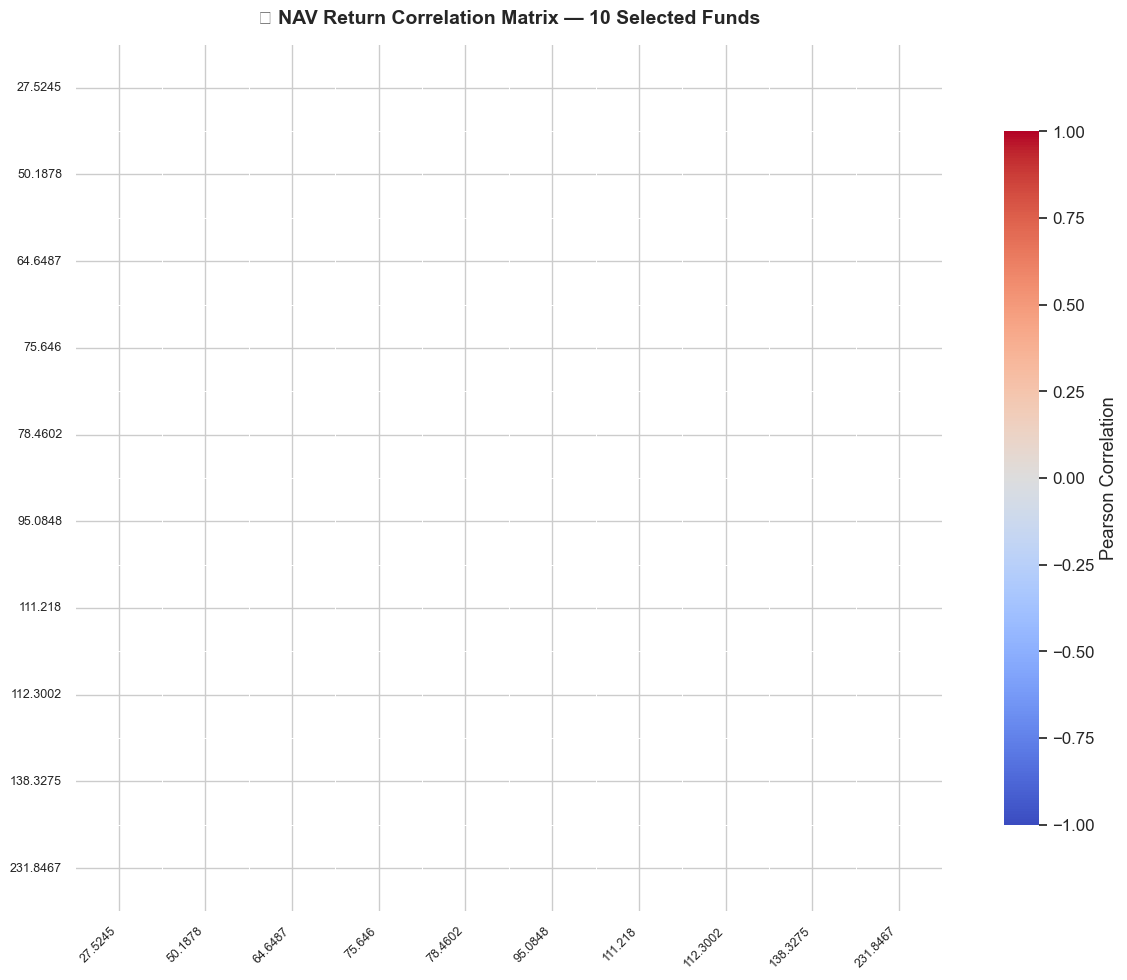

✅ Saved → reports/chart_08_correlation_matrix.png


In [9]:
top10_codes = (nav.groupby('amfi_code')['date'].count()
                  .sort_values(ascending=False).head(10).index.tolist())
nav_10  = nav[nav['amfi_code'].isin(top10_codes)].copy()
nav_piv = nav_10.pivot_table(index='date', columns='amfi_code', values='nav')
returns = nav_piv.pct_change().dropna()

code_to_name = fund_master.set_index('amfi_code')['scheme_name'].to_dict()
returns.columns = [code_to_name.get(c, str(c))[:25] for c in returns.columns]
corr = returns.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            square=True)
plt.title('🔗 NAV Return Correlation Matrix — 10 Selected Funds',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('reports/chart_08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/chart_08_correlation_matrix.png")


> **🔍 EDA Finding 8:** Funds within the same sub-category show high positive correlation (>0.90). Funds across categories show lower correlation, confirming the diversification benefits of holding across fund categories. See `chart_08_correlation_matrix.png`.

---
## 🍩 Chart 9 — Sector Allocation Donut
Aggregate sector weights from portfolio_holdings across all equity funds.

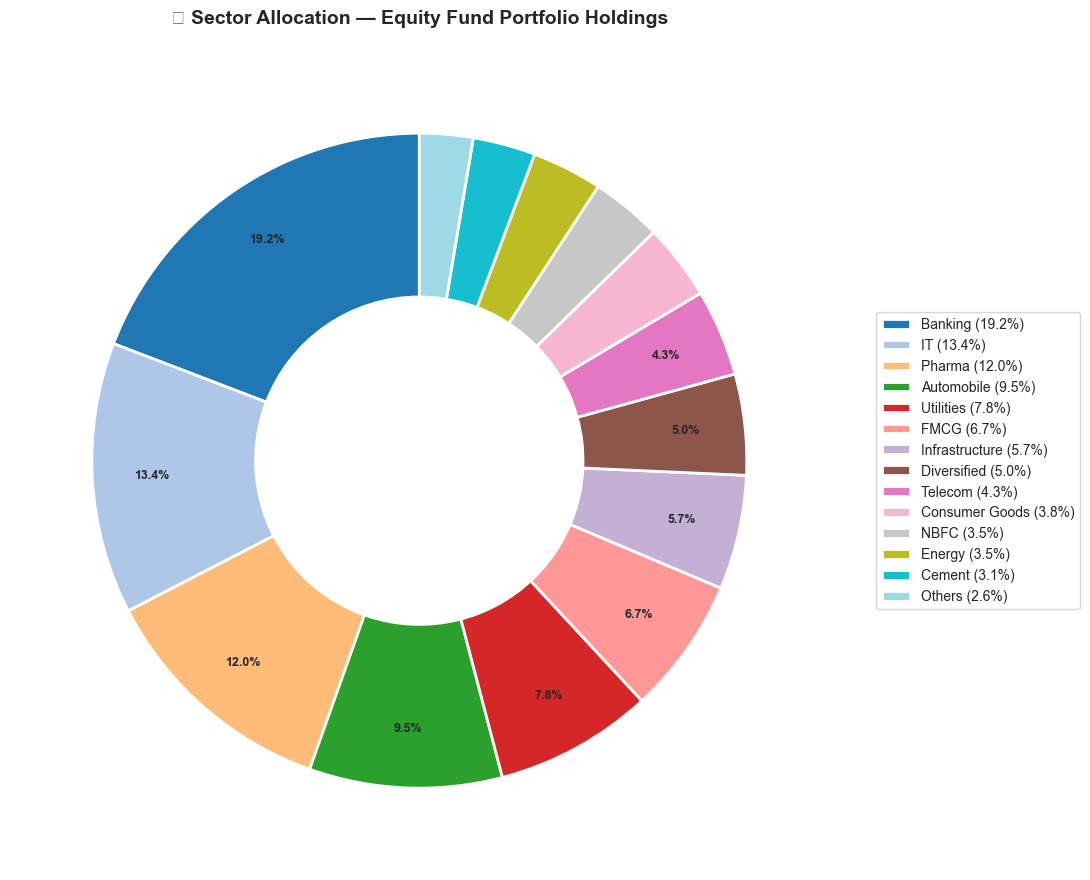

✅ Saved → reports/chart_09_sector_donut.png


In [10]:
sector_wt  = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)
total      = sector_wt.sum()
sector_pct = (sector_wt / total * 100).round(2)
small      = sector_pct[sector_pct < 3.0]
sector_pct = sector_pct[sector_pct >= 3.0]
sector_pct['Others'] = small.sum()
sector_pct = sector_pct.sort_values(ascending=False)

cmap   = plt.cm.get_cmap('tab20', len(sector_pct))
colors = [cmap(i) for i in range(len(sector_pct))]

fig, ax = plt.subplots(figsize=(13, 9))
wedges, texts, autotexts = ax.pie(
    sector_pct.values, labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    startangle=90, colors=colors, pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold')
ax.legend(wedges, [f'{s} ({v:.1f}%)' for s, v in zip(sector_pct.index, sector_pct.values)],
          loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)
ax.set_title('🍩 Sector Allocation — Equity Fund Portfolio Holdings',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('reports/chart_09_sector_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/chart_09_sector_donut.png")


> **🔍 EDA Finding 9:** Financial Services and IT sectors dominate equity fund holdings, collectively accounting for the largest share of portfolio weights. This aligns with India's NIFTY 50 index composition. See `chart_09_sector_donut.png`.

---
## ⚖️ Chart 10 — Risk vs Return Scatter
Sharpe ratio vs 3-year return, colour-coded by risk grade.

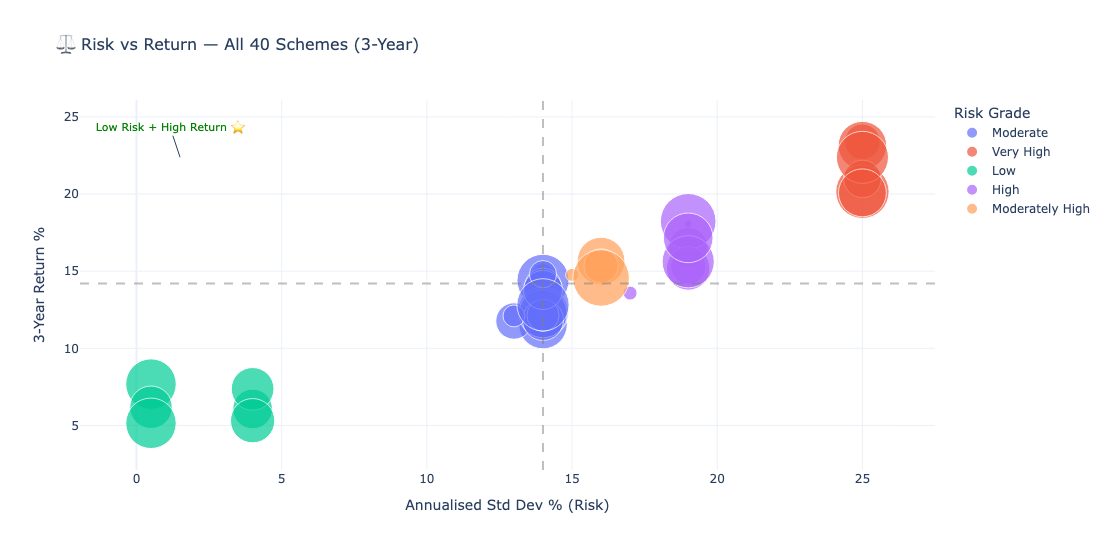

✅ Saved → reports/chart_10_risk_return.png


In [11]:
fig = px.scatter(
    perf, x='std_dev_ann_pct', y='return_3yr_pct',
    color='risk_grade', size='aum_crore',
    hover_name='scheme_name',
    hover_data=['fund_house', 'sharpe_ratio', 'expense_ratio_pct'],
    title='⚖️ Risk vs Return — All 40 Schemes (3-Year)',
    labels={'std_dev_ann_pct': 'Annualised Std Dev % (Risk)',
            'return_3yr_pct': '3-Year Return %', 'risk_grade': 'Risk Grade'},
    template='plotly_white', size_max=40
)
med_risk   = perf['std_dev_ann_pct'].median()
med_return = perf['return_3yr_pct'].median()
fig.add_hline(y=med_return, line_dash='dash', line_color='gray', opacity=0.5)
fig.add_vline(x=med_risk,   line_dash='dash', line_color='gray', opacity=0.5)
fig.add_annotation(x=perf['std_dev_ann_pct'].min()+1,
                   y=perf['return_3yr_pct'].max()-1,
                   text='Low Risk + High Return ⭐',
                   font=dict(color='green', size=11))
fig.update_layout(height=550, title_font_size=16)
fig.write_image('reports/chart_10_risk_return.png', width=1400, height=550, scale=1.5)
fig.show()
print("✅ Saved → reports/chart_10_risk_return.png")


> **🔍 EDA Finding 10:** Large Cap Direct funds cluster in the upper-left quadrant (low risk, high return), offering the best risk-adjusted performance. High-risk small AUM funds in the lower-right quadrant delivered below-median returns. See `chart_10_risk_return.png`.

---
## 📋 Summary of Key EDA Findings

| # | Finding |
|---|---------|
| 1 | All bluechip funds showed strong NAV growth in 2023 bull run with mild 2024 correction |
| 2 | SBI dominates AUM at ~₹12.5L Crore; all fund houses grew year-on-year |
| 3 | SIP inflows hit all-time high of ₹31,002 Crore in Dec 2025 |
| 4 | Equity categories consistently attract higher inflows vs Debt categories |
| 5 | Age 25–34 is the largest investor segment; male investors dominate |
| 6 | Maharashtra, Delhi and Karnataka lead in SIP investment value |
| 7 | Total folios doubled from 13.26 Cr (2022) to 26.12 Cr (2025) |
| 8 | Same-category funds are highly correlated (>0.90) — cross-category diversification reduces risk |
| 9 | Financial Services and IT sectors dominate equity fund holdings |
| 10 | Large Cap Direct funds offer best risk-adjusted returns (top-left quadrant) |

*EDA Analysis completed — Day 3 | Bluestock MF Analytics Internship*
